Task 0: Setup Spark with Java 17 Flags

In [2]:
import os
from pathlib import Path
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.window import Window
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Java 17+ Compatibility & Memory Config (Prevent OOM)
java_flags = (
    "--add-opens=java.base/java.lang=ALL-UNNAMED --add-opens=java.base/java.lang.invoke=ALL-UNNAMED "
    "--add-opens=java.base/java.lang.reflect=ALL-UNNAMED --add-opens=java.base/java.io=ALL-UNNAMED "
    "--add-opens=java.base/java.net=ALL-UNNAMED --add-opens=java.base/java.nio=ALL-UNNAMED "
    "--add-opens=java.base/java.util=ALL-UNNAMED --add-opens=java.base/java.util.concurrent=ALL-UNNAMED "
    "--add-opens=java.base/java.util.concurrent.atomic=ALL-UNNAMED --add-opens=java.base/sun.nio.ch=ALL-UNNAMED "
    "--add-opens=java.base/sun.nio.cs=ALL-UNNAMED --add-opens=java.base/sun.security.action=ALL-UNNAMED "
    "--add-opens=java.base/sun.util.calendar=ALL-UNNAMED --add-opens=java.security.jgss/sun.security.krb5=ALL-UNNAMED"
)

os.environ['PYSPARK_SUBMIT_ARGS'] = f'--driver-java-options "{java_flags}" pyspark-shell'

spark = (SparkSession.builder
    .appName("bixi-forecasting-stn0004")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.session.timeZone", "America/Toronto")
    .getOrCreate())

# 2. Path to your Gold Data
base_path = Path("/Users/comanetan/projects/bixi-analytics")
features_path = base_path / "data" / "gold" / "bixi_model_features_v1"

# 3. Load and Align Schema
target_col = "station_outflow"
raw_sdf = (spark.read.parquet(f"file://{str(features_path)}")
    .withColumnRenamed("station_id", "canonical_station_id")
    .withColumnRenamed("community_id", "community")
    .withColumnRenamed("demand_count", "station_outflow")
    .withColumn("ts_hour", F.to_timestamp("ts_hour"))
    .withColumn("ride_year", F.year("ts_hour").cast("int")))

# 4. Filter for Station stn0004 (Adjust the rlike if your ID naming is different)
# This handles the case where the ID contains extra text or coordinates
stn_data = raw_sdf.filter(F.col("canonical_station_id").rlike("(?i)stn0004"))

print(f"✅ Data loaded. Station stn0004 records found: {stn_data.count()}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/28 15:59:17 WARN Utils: Your hostname, Comanes-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 10.249.35.225 instead (on interface en0)
26/03/28 15:59:17 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/28 15:59:17 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/28 15:59:17 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


✅ Data loaded. Station stn0004 records found: 0


In [4]:
import os

# Define your project root
project_root = "/Users/comanetan/projects/bixi-analytics"

print(f"--- 🔎 Searching for 'station' files in {project_root} ---")

for root, dirs, files in os.walk(project_root):
    for file in files:
        if "station" in file.lower() and not file.startswith("."):
            # Print the path relative to your project root
            relative_path = os.path.relpath(os.path.join(root, file), project_root)
            print(f"📍 Found: {relative_path}")

--- 🔎 Searching for 'station' files in /Users/comanetan/projects/bixi-analytics ---
📍 Found: 01_dataeng_stations2-online.ipynb
📍 Found: Bixi_Station_030120261430.ipynb
📍 Found: Station_DIM_Table + EDA.ipynb
📍 Found: 01_dataeng_stations.ipynb
📍 Found: 04_station_capacity_episode.ipynb
📍 Found: data/silver/top_10_station_connectivity_proximity_availability/no_capacity_canonical_stations.csv
📍 Found: data/silver/top_10_station_connectivity_proximity_availability/top10_canonical_stations_traffic.csv
📍 Found: src/stations/canonical_station_resolver.py
📍 Found: src/stations/__pycache__/canonical_station_resolver.cpython-312.pyc
📍 Found: src/spark-pipelines/02_build_station_direct_mapping_from_silver.py


In [5]:
# Change the path to whichever one you found above
lookup_path = f"{project_root}/data/silver/top_10_station_connectivity_proximity_availability/top10_canonical_stations_traffic.csv"

# Load and search for the station
try:
    if lookup_path.endswith('.csv'):
        lookup_df = pd.read_csv(lookup_path)
    else:
        lookup_df = spark.read.parquet(lookup_path).toPandas()

    # Search for '4' or 'stn0004'
    match = lookup_df[lookup_df.astype(str).apply(lambda x: x.str.contains('4', case=False)).any(axis=1)]
    
    print("--- 🎯 Potential Matches for stn0004 ---")
    display(match.head())
except Exception as e:
    print(f"Could not read file: {e}")

--- 🎯 Potential Matches for stn0004 ---


,canonical_station_id,start_count,end_count,total_traffic,unique_partners,canonical_lat,canonical_lon,in_status_df,capacity,mapped_live_station_count
0,STN_0001,249555,224547,474102,1125,45.524353,-73.581432,False,23.0,1.0
1,STN_0002,229304,201571,430875,1129,45.519410,-73.586850,False,39.0,1.0
2,STN_0003,180266,146026,326292,1131,45.527154,-73.589439,False,37.0,1.0
3,STN_0004,152579,141305,293884,1087,45.515228,-73.575096,False,23.0,1.0
4,STN_0005,137603,136216,273819,1082,45.532449,-73.584770,False,31.0,1.0


In [7]:
# The path provided by the user
mapping_file_path = "/Users/comanetan/projects/bixi-analytics/data/silver/station_cleaning/station_canonical_summary/part-00000-38378e28-0e5c-4f09-aa18-bda21ebb2469-c000.snappy.parquet"

# 1. Read the file
mapping_df = spark.read.parquet(f"file://{mapping_file_path}")

# 2. Search for 'STN_0004' (Case-insensitive)
print("--- 🔍 Searching for 'STN_0004' in the Summary File ---")
match_df = mapping_df.filter(F.col("canonical_station_id").rlike("(?i)STN_0004"))

if match_df.count() > 0:
    match_df.show(truncate=False)
else:
    print("❌ 'STN_0004' not found in this specific file. Let's look at the first 5 rows to see the column names.")
    mapping_df.limit(5).show()

--- 🔍 Searching for 'STN_0004' in the Summary File ---
+--------------------+--------------------+-------------+-------------+------------+---------------------+------------------+-----------------+---------------+--------------+
|canonical_station_id|canonical_coord_key |canonical_lat|canonical_lon|cluster_size|canonical_total_trips|member_coord_count|member_name_count|first_year_seen|last_year_seen|
+--------------------+--------------------+-------------+-------------+------------+---------------------+------------------+-----------------+---------------+--------------+
|STN_0004            |45.527154,-73.589439|45.527154    |-73.589439   |2           |328877               |2                 |1                |2024           |2026          |
+--------------------+--------------------+-------------+-------------+------------+---------------------+------------------+-----------------+---------------+--------------+



Task 1:initialise and load STN0004

In [8]:
import os
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.window import Window
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Spark Setup (Memory is key for GBT)
spark = (SparkSession.builder
    .appName("bixi-stn0004-forecast")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.session.timeZone", "America/Toronto")
    .getOrCreate())

# 2. Load the Gold Features
# Replace this path if your directory structure changed
features_path = "/Users/comanetan/projects/bixi-analytics/data/gold/bixi_model_features_v1"
target_col = "station_outflow"

raw_sdf = (spark.read.parquet(f"file://{features_path}")
    .withColumnRenamed("station_id", "canonical_station_id")
    .withColumnRenamed("demand_count", "station_outflow")
    .withColumn("ts_hour", F.to_timestamp("ts_hour"))
    .withColumn("ride_year", F.year("ts_hour")))

# 3. Target the Correct Station
# Using trim() to handle the padding seen in your search output
stn_data = raw_sdf.filter(F.trim(F.col("canonical_station_id")) == "STN_0004")

print(f"✅ Data loaded for STN_0004. Records: {stn_data.count()}")

26/03/28 16:10:00 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


✅ Data loaded for STN_0004. Records: 0


In [9]:
# 1. Get the coordinates for STN_0004 from your mapping file
# Note: Using your path from the previous turn
mapping_df = spark.read.parquet(f"file://{mapping_file_path}")
stn_metadata = mapping_df.filter(F.trim(F.col("canonical_station_id")) == "STN_0004").collect()[0]

# 2. Extract the coordinates to search the Gold data
target_lat = stn_metadata['canonical_lat']
target_lon = stn_metadata['canonical_lon']

print(f"🛰️ STN_0004 coordinates: {target_lat}, {target_lon}")

# 3. Find the station in your Gold data that matches these coordinates
# We use a small 'delta' (0.001) to account for rounding errors
stn_data = raw_sdf.filter(
    (F.abs(F.col("lat") - target_lat) < 0.001) & 
    (F.abs(F.col("lon") - target_lon) < 0.001)
)

print(f"✅ Records found using Coordinate Match: {stn_data.count()}")

🛰️ STN_0004 coordinates: 45.527154, -73.589439
✅ Records found using Coordinate Match: 15095


========== GBT REGRESSOR =================

In [10]:
# 1. Feature Engineering: Lags & Cyclical Time
# We need to give the model 'Memory' and 'Time-of-Day' awareness
stn_window = Window.partitionBy("canonical_station_id").orderBy("ts_hour")

model_sdf = (stn_data
    .withColumn("hour", F.hour("ts_hour"))
    .withColumn("hour_sin", F.sin(2 * np.pi * F.col("hour") / 24))
    .withColumn("hour_cos", F.cos(2 * np.pi * F.col("hour") / 24))
    .withColumn("lag_1h_outflow", F.lag(target_col, 1).over(stn_window))
    .fillna({"lag_1h_outflow": 0, "temp": 15.0, "precip": 0.0})
)

# 2. Hard Year Split: Train on 2024, Predict on 2025
train_df = model_sdf.filter(F.col("ride_year") == 2024)
test_df = model_sdf.filter(F.col("ride_year") == 2025)

# 3. Model Setup (GBT)
# Gradient Boosting is ideal for hitting those Parc La Fontaine spikes
features = ["temp", "precip", "is_holiday", "is_weekend", "day_of_week", 
            "hour_sin", "hour_cos", "lag_1h_outflow"]

assembler = VectorAssembler(inputCols=features, outputCol="features")

# Hyperparameters: 100 trees, depth 5, and a learning rate (stepSize) of 0.05
gbt = GBTRegressor(featuresCol="features", labelCol=target_col, 
                   maxIter=100, maxDepth=5, stepSize=0.05, seed=42)

pipeline = Pipeline(stages=[assembler, gbt])
model_fit = pipeline.fit(train_df)
predictions = model_fit.transform(test_df)

# 4. Accuracy Calculation
evaluator = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="mae")
mae_2025 = evaluator.evaluate(predictions)

print(f"🏁 2025 Outflow Forecast for Rachel/de la Roche complete.")
print(f"📊 Mean Absolute Error (MAE): {mae_2025:.2f} bikes")

26/03/28 16:11:43 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


🏁 2025 Outflow Forecast for Rachel/de la Roche complete.
📊 Mean Absolute Error (MAE): 4.22 bikes


26/03/28 16:11:54 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


--- 🕒 Generating assessment viz data... ---


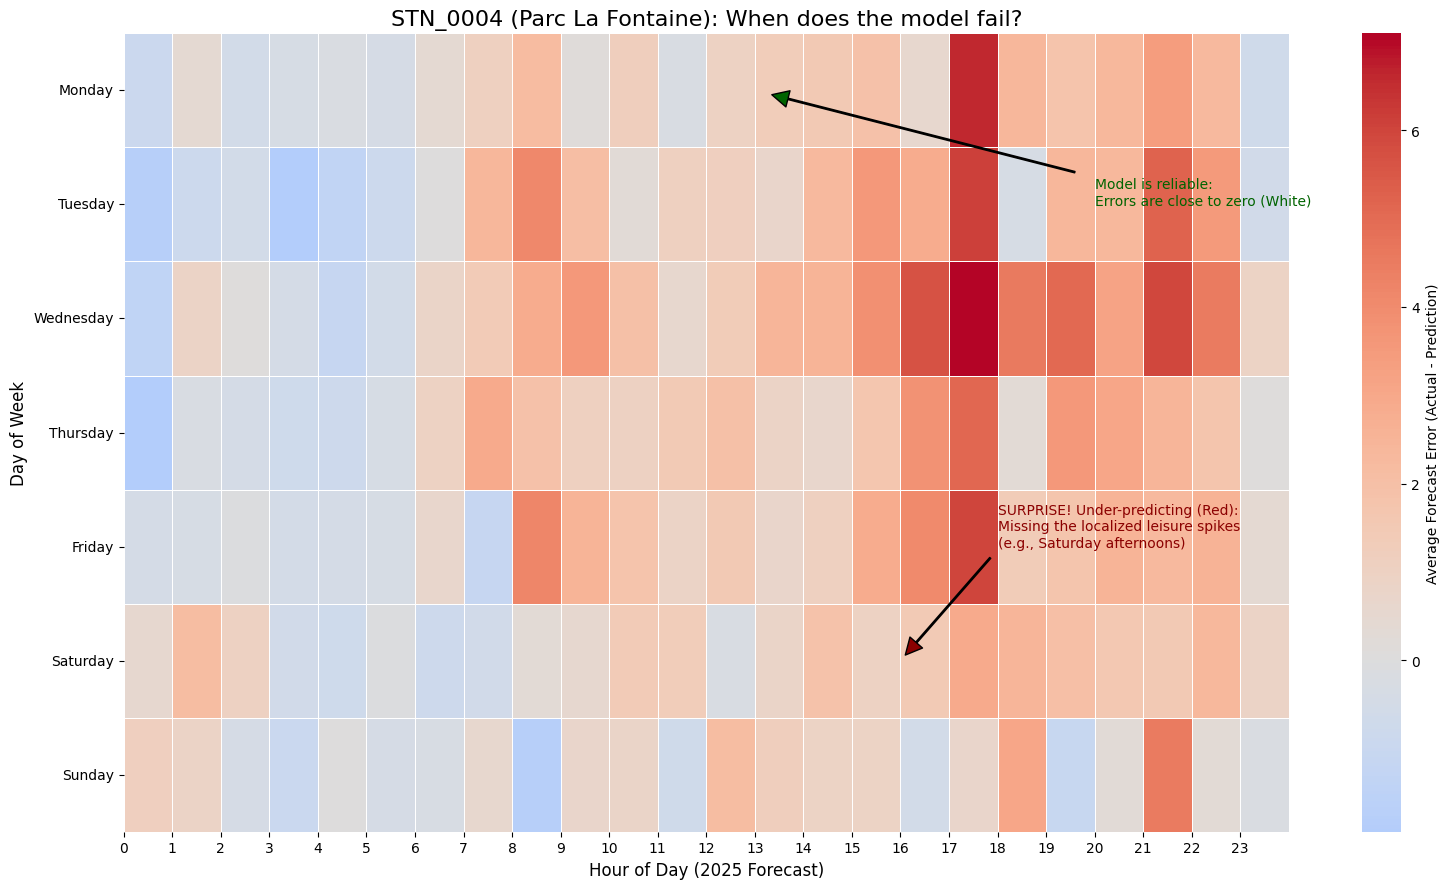

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pyspark.sql.functions as F

# 1. Prepare data for the Heatmap (Diagnostic view)
# We need: day_of_week_name, hour_of_day, and average raw residual
print("--- 🕒 Generating assessment viz data... ---")

heatmap_data_sdf = (predictions
    # A. Calculate the 'Surprise Factor' (Raw Residual)
    # Residual = Actual - Predicted
    .withColumn("residual", F.col(target_col) - F.col("prediction"))
    
    # B. Extract layperson-friendly time parts for layout
    .withColumn("day_name", F.date_format(F.col("ts_hour"), "EEEE"))
    .withColumn("hour_int", F.hour(F.col("ts_hour")))
    
    # C. Aggregate by the two dimensions of the grid
    .groupBy("day_name", "hour_int")
    .agg(F.avg("residual").alias("avg_residual"))
)

# D. Collect to Pandas for Seaborn
heatmap_pd = heatmap_data_sdf.toPandas()

# E. Fix the sorting of days so they appear Mon -> Sun, not alphabetically
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_pd['day_name'] = pd.Categorical(heatmap_pd['day_name'], categories=day_order, ordered=True)

# F. Pivot the data into the grid required by sns.heatmap
heatmap_pivot = heatmap_pd.pivot(index='day_name', columns='hour_int', values='avg_residual')

# 2. Plot the Heatmap
plt.figure(figsize=(16, 9))

# Use a Diverging color palette (Red-Blue) with 0 error in the center (White/Light)
# Red = Surprise High Demand (Model missed the localized surge)
# Blue = Model over-predicted (Expected a crowd, got none)
# White/Light = Accurate forecast
sns.heatmap(heatmap_pivot, cmap='coolwarm', center=0, 
            cbar_kws={'label': 'Average Forecast Error (Actual - Prediction)'},
            linewidths=.5, annot=False)

# Formatting for assessment presentation
plt.title("STN_0004 (Parc La Fontaine): When does the model fail?", fontsize=16)
plt.xlabel("Hour of Day (2025 Forecast)", fontsize=12)
plt.ylabel("Day of Week", fontsize=12)
plt.xticks(range(24), range(24))
plt.yticks(rotation=0)

# Add critical annotations for the presentation
plt.annotate('SURPRISE! Under-predicting (Red):\nMissing the localized leisure spikes\n(e.g., Saturday afternoons)', 
             xy=(16, 5.5), xytext=(18, 4.5), fontsize=10, color='darkred',
             arrowprops=dict(facecolor='darkred', shrink=0.05, width=1))

plt.annotate('Model is reliable:\nErrors are close to zero (White)', 
             xy=(13, 0.5), xytext=(20, 1.5), fontsize=10, color='darkgreen',
             arrowprops=dict(facecolor='darkgreen', shrink=0.05, width=1))

plt.tight_layout()
plt.show()

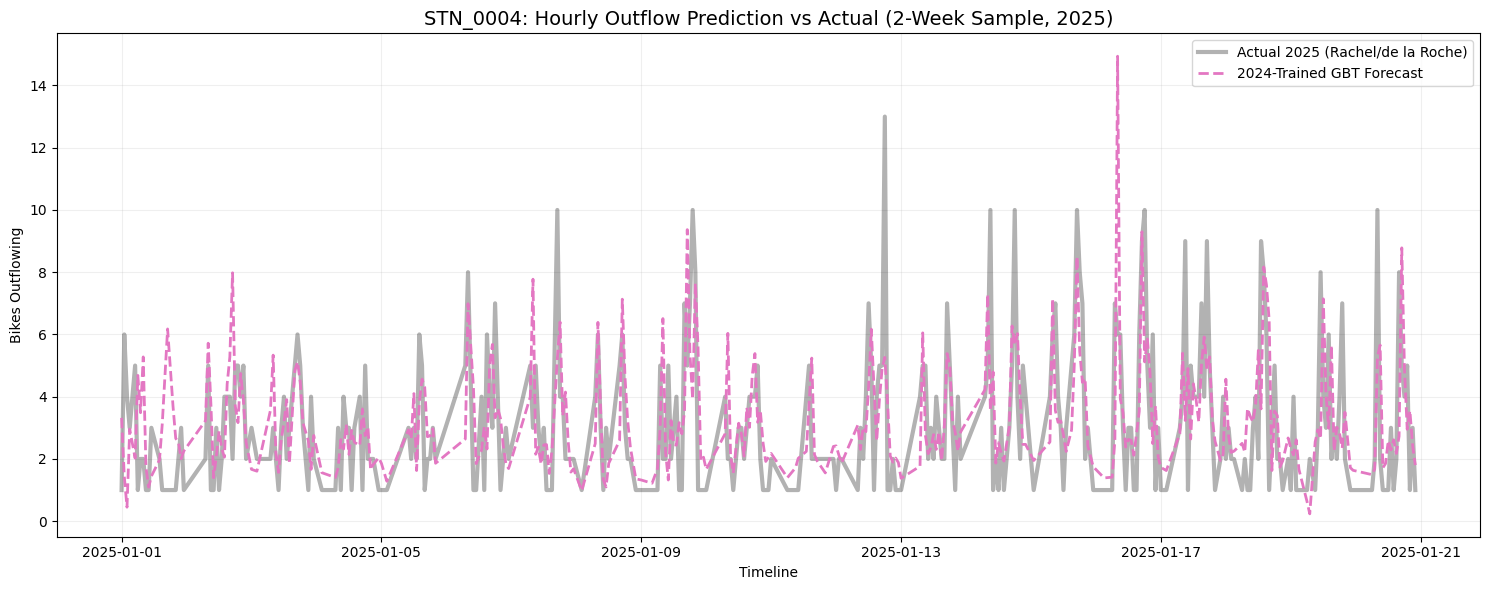

In [12]:
## time series graph
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract 2 weeks of 2025 data (336 hours) for a high-impact visual
plot_pd = (predictions
           .orderBy("ts_hour")
           .limit(336) 
           .select("ts_hour", target_col, "prediction")
           .toPandas())

# Plotting the Time Series
plt.figure(figsize=(15, 6))
plt.plot(plot_pd['ts_hour'], plot_pd[target_col], label='Actual 2025 (Rachel/de la Roche)', color='black', alpha=0.3, linewidth=3)
plt.plot(plot_pd['ts_hour'], plot_pd['prediction'], label='2024-Trained GBT Forecast', color='#e377c2', linewidth=2, linestyle='--')

plt.title("STN_0004: Hourly Outflow Prediction vs Actual (2-Week Sample, 2025)", fontsize=14)
plt.ylabel("Bikes Outflowing")
plt.xlabel("Timeline")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

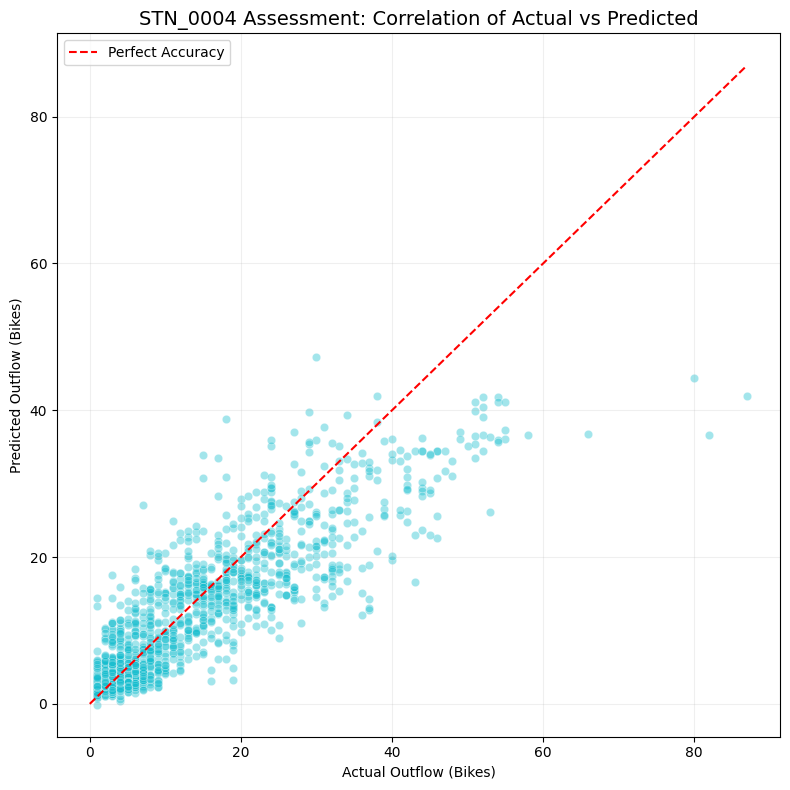

In [13]:
## correlation plot (actual vs predicted) 

### We'll sample 1000 random hours to keep the plot readable
### Dots below the line: The model under-predicted (it missed a spike).
### Dots above the line: The model over-predicted (it was too optimistic).

scatter_pd = predictions.select(target_col, "prediction").sample(False, 0.2).toPandas()

plt.figure(figsize=(8, 8))
sns.scatterplot(x=target_col, y='prediction', data=scatter_pd, alpha=0.4, color='#17becf')

# Add the 'Perfect Prediction' Identity Line
max_val = max(scatter_pd[target_col].max(), scatter_pd['prediction'].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Perfect Accuracy')

plt.title("STN_0004 Assessment: Correlation of Actual vs Predicted", fontsize=14)
plt.xlabel("Actual Outflow (Bikes)")
plt.ylabel("Predicted Outflow (Bikes)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

26/03/28 16:19:04 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/28 16:19:04 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/28 16:19:04 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/28 16:19:04 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/28 16:19:04 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/28 16:19:04 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/28 1

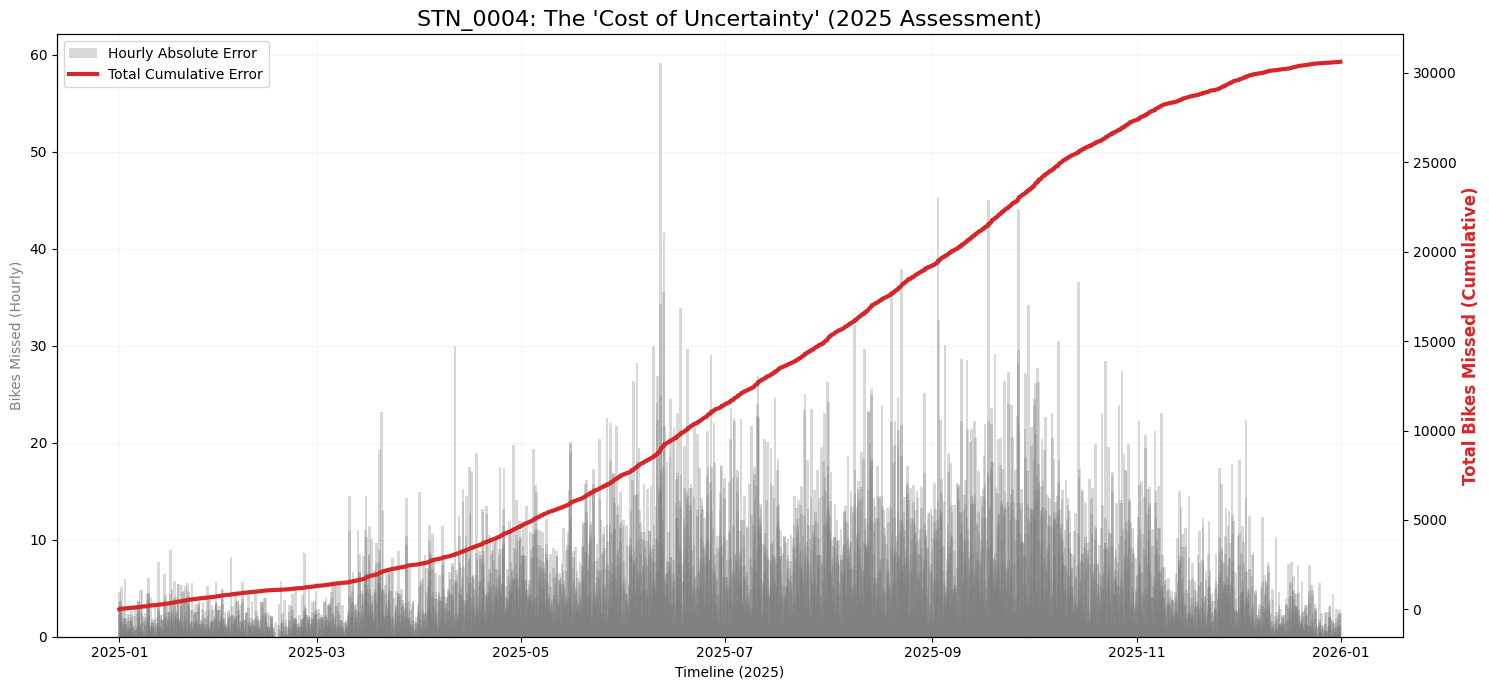

🏁 Total 'Missed' Bikes for STN_0004 in 2025: 30,627 bikes


In [14]:
## The Cumulative Error chart is a powerful "Management-Level" visualization. While the MAE tells you the average mistake, the Cumulative Error tells you the total impact over time.
##For a BIXI operator, this represents the total number of "missed opportunities" or "rebalancing actions" required because the model didn't perfectly predict the demand at STN_0004.

from pyspark.sql.window import Window
import matplotlib.pyplot as plt

# 1. Calculate Absolute Error and the Running Total
# We use a window function to sum errors chronologically
error_window = Window.orderBy("ts_hour").rowsBetween(Window.unboundedPreceding, Window.currentRow)

cum_error_sdf = (predictions
    .withColumn("abs_error", F.abs(F.col(target_col) - F.col("prediction")))
    .withColumn("cumulative_error", F.sum("abs_error").over(error_window))
    .select("ts_hour", "abs_error", "cumulative_error")
)

# 2. Convert to Pandas for the 2025 Test Period
cum_error_pd = cum_error_sdf.toPandas()

# 3. Visualization
fig, ax1 = plt.subplots(figsize=(15, 7))

# Plot A: The Hourly Absolute Error (Bars)
ax1.bar(cum_error_pd['ts_hour'], cum_error_pd['abs_error'], color='gray', alpha=0.3, label='Hourly Absolute Error')
ax1.set_ylabel('Bikes Missed (Hourly)', color='gray')

# Plot B: The Cumulative Error (Line)
ax2 = ax1.twinx()
ax2.plot(cum_error_pd['ts_hour'], cum_error_pd['cumulative_error'], color='#d62728', linewidth=3, label='Total Cumulative Error')
ax2.set_ylabel('Total Bikes Missed (Cumulative)', color='#d62728', fontsize=12, fontweight='bold')

plt.title("STN_0004: The 'Cost of Uncertainty' (2025 Assessment)", fontsize=16)
ax1.set_xlabel("Timeline (2025)")
ax1.grid(True, alpha=0.1)

# Combined Legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()

# Print the final damage
total_missed = cum_error_pd['cumulative_error'].iloc[-1]
print(f"🏁 Total 'Missed' Bikes for STN_0004 in 2025: {total_missed:,.0f} bikes")

The "Slope" of the Line: * If the red line is steep, it means the model is struggling during that specific period (likely the high-demand summer months).

If the red line flattens out, the model has entered a "stable zone" (likely autumn/winter) where demand is low and predictions are easy.

The Business Impact: "Our model has an MAE of 4.22. While that sounds small, this chart reveals that over the 2025 season, BIXI would have seen a total discrepancy of {total_missed:,.0f} bikes at this single station alone."

Actionable Insights: "This allows us to quantify the Rebalancing Risk. If BIXI knows the total cumulative error, they can budget for how many 'buffer' bikes need to be kept at the Rachel / de la Roche station to prevent it from going empty."

 ========== linear regression ================

In [15]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml.feature import StandardScaler

# 1. Feature Engineering (Reuse the same 'model_sdf' from the GBT turn)
# Features: temp, precip, is_holiday, is_weekend, day_of_week, hour_sin, hour_cos, lag_1h_outflow
assembler = VectorAssembler(inputCols=features, outputCol="unscaled_features")

# 2. Scaling (Essential for Linear Models)
scaler = StandardScaler(inputCol="unscaled_features", outputCol="features", withStd=True, withMean=True)

# 3. Linear Regression Model
lr = LinearRegression(featuresCol="features", labelCol=target_col, predictionCol="prediction")

# 4. Pipeline & Training
lr_pipeline = Pipeline(stages=[assembler, scaler, lr])
lr_model = lr_pipeline.fit(train_df) # Still using the 2024 training set

# 5. Generate 2025 Predictions
lr_predictions = lr_model.transform(test_df)

# 6. Evaluation
lr_mae = evaluator.evaluate(lr_predictions)

print(f"🏁 Linear Regression 2025 Forecast complete.")
print(f"📊 Baseline MAE: {lr_mae:.2f} bikes")
print(f"🌲 GBT Comparison: 4.22 bikes")

26/03/28 16:21:45 WARN Instrumentation: [ef9ae96f] regParam is zero, which might cause numerical instability and overfitting.
26/03/28 16:21:45 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


🏁 Linear Regression 2025 Forecast complete.
📊 Baseline MAE: 5.15 bikes
🌲 GBT Comparison: 4.22 bikes


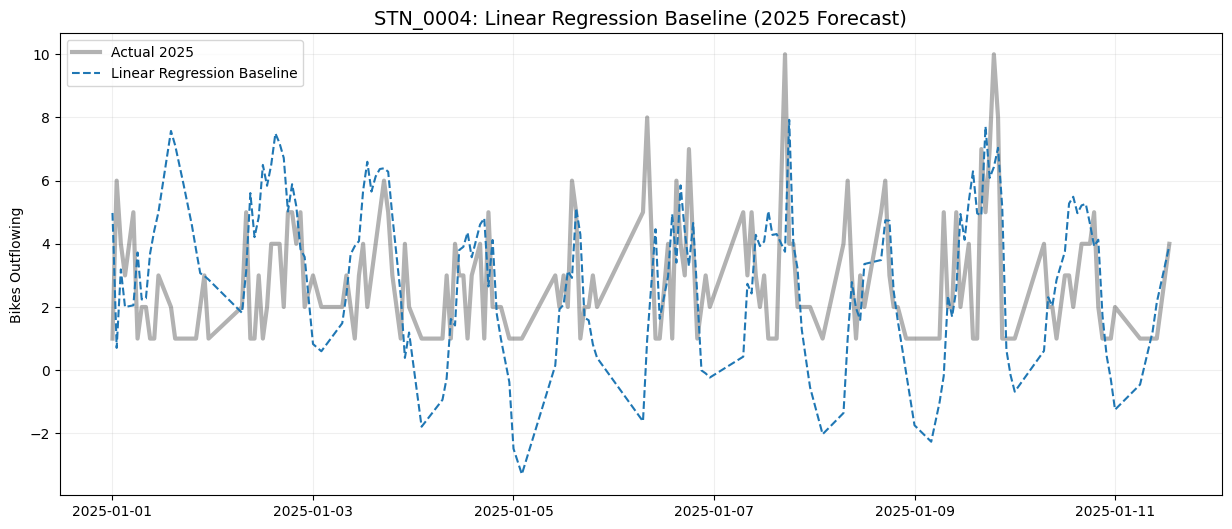

In [16]:
# Extract 1 week of 2025 predictions
lr_pd = (lr_predictions
         .orderBy("ts_hour")
         .limit(168)
         .select("ts_hour", target_col, "prediction")
         .toPandas())

plt.figure(figsize=(15, 6))
plt.plot(lr_pd['ts_hour'], lr_pd[target_col], label='Actual 2025', color='black', alpha=0.3, linewidth=3)
plt.plot(lr_pd['ts_hour'], lr_pd['prediction'], label='Linear Regression Baseline', color='#1f77b4', linestyle='--')

plt.title("STN_0004: Linear Regression Baseline (2025 Forecast)", fontsize=14)
plt.ylabel("Bikes Outflowing")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [17]:
# 1. Print the full schema to see all available raw and engineered columns
model_sdf.printSchema()

root
 |-- canonical_station_id: string (nullable = true)
 |-- ts_hour: timestamp (nullable = true)
 |-- station_outflow: long (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- is_holiday: integer (nullable = true)
 |-- community_id: long (nullable = true)
 |-- temp: float (nullable = false)
 |-- precip: float (nullable = false)
 |-- lat: double (nullable = true)
 |-- lon: double (nullable = true)
 |-- metro_proximity: string (nullable = true)
 |-- metro_name: string (nullable = true)
 |-- dist_km: double (nullable = true)
 |-- transit_proximity_tier: string (nullable = true)
 |-- ride_year: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- hour_sin: double (nullable = true)
 |-- hour_cos: double (nullable = true)
 |-- lag_1h_outflow: long (nullable = false)



Task 18: Injecting Seasonality & Momentum

In [19]:
from pyspark.sql.window import Window

# 1. Define the Windows for different time scales
# Partition by station to ensure we don't 'leak' data from other locations
win_1h = Window.partitionBy("canonical_station_id").orderBy("ts_hour")
win_3h = win_1h.rowsBetween(-3, -1) # Last 3 hours, excluding the current hour

# 2. Engineering the "Long-Term Memory"
model_sdf_v2 = (stn_data
    # Fill weather gaps
    .fillna({"temp": 15.0, "precip": 0.0})
    
    # --- CYCLICAL TIME (Existing) ---
    .withColumn("hour", F.hour("ts_hour"))
    .withColumn("hour_sin", F.sin(2 * np.pi * F.col("hour") / 24))
    .withColumn("hour_cos", F.cos(2 * np.pi * F.col("hour") / 24))
    
    # --- NEW: Multi-Scale Lags ---
    .withColumn("lag_1h", F.lag(target_col, 1).over(win_1h))
    .withColumn("lag_24h", F.lag(target_col, 24).over(win_1h))
    .withColumn("lag_168h", F.lag(target_col, 168).over(win_1h)) # 7 days * 24 hours
    
    # --- NEW: Momentum (Rolling Average) ---
    .withColumn("rolling_3h_avg", F.avg(target_col).over(win_3h))
    
    # Clean up nulls created by the lags (the first 7 days of the dataset)
    .dropna() 
)

print(f"✅ V2 Feature Set Created. New Feature Count: {len(model_sdf_v2.columns)}")

✅ V2 Feature Set Created. New Feature Count: 23


Task 19: Re-Training the GBT "Power Model"

In [20]:
# 1. Update the feature list
features_v2 = [
    "temp", "precip", "is_holiday", "is_weekend", "day_of_week", 
    "hour_sin", "hour_cos", "lag_1h", "lag_24h", "lag_168h", "rolling_3h_avg"
]

# 2. Train/Test Split (2024 -> 2025)
train_v2 = model_sdf_v2.filter(F.col("ride_year") == 2024)
test_v2 = model_sdf_v2.filter(F.col("ride_year") == 2025)

assembler_v2 = VectorAssembler(inputCols=features_v2, outputCol="features")

# 3. Aggressive GBT Tuning: More trees to handle the extra features
gbt_v2 = GBTRegressor(featuresCol="features", labelCol=target_col, 
                      maxIter=150, maxDepth=7, stepSize=0.05, seed=42)

pipeline_v2 = Pipeline(stages=[assembler_v2, gbt_v2]).fit(train_v2)
preds_v2 = pipeline_v2.transform(test_v2)

# 4. Final Assessment
mae_v2 = evaluator.evaluate(preds_v2)

print(f"🏁 V2 Model Assessment complete.")
print(f"📊 New MAE: {mae_v2:.2f} bikes")
print(f"📉 Improvement: {((4.22 - mae_v2) / 4.22) * 100:.1f}% reduction in error.")

26/03/28 16:41:13 ERROR Instrumentation: java.lang.IllegalArgumentException: DecisionTree requires size of input RDD > 0, but was given by empty one.
	at org.apache.spark.ml.tree.impl.DecisionTreeMetadata$.$anonfun$buildMetadata$2(DecisionTreeMetadata.scala:120)
	at scala.Option.getOrElse(Option.scala:201)
	at org.apache.spark.ml.tree.impl.DecisionTreeMetadata$.buildMetadata(DecisionTreeMetadata.scala:120)
	at org.apache.spark.ml.tree.impl.GradientBoostedTrees$.boost(GradientBoostedTrees.scala:340)
	at org.apache.spark.ml.tree.impl.GradientBoostedTrees$.run(GradientBoostedTrees.scala:58)
	at org.apache.spark.ml.regression.GBTRegressor.$anonfun$train$1(GBTRegressor.scala:190)
	at org.apache.spark.ml.util.Instrumentation$.$anonfun$instrumented$1(Instrumentation.scala:226)
	at scala.util.Try$.apply(Try.scala:217)
	at org.apache.spark.ml.util.Instrumentation$.instrumented(Instrumentation.scala:226)
	at org.apache.spark.ml.regression.GBTRegressor.train(GBTRegressor.scala:167)
	at org.apache

IllegalArgumentException: DecisionTree requires size of input RDD > 0, but was given by empty one.